# Forecasting an InSAR displacement series with PyTorch

A runnable version of the original experiment, using the same reproducible sample
series as `cnn_insar_univariate_forecasting.ipynb`. The network preserves the
original causal convolution, two LSTMs and scalar output. No external CSV or
saved model is required.


## Experiment

Train a one-step model on the first part of one displacement series, then compare
rolling predictions that receive newly observed measurements with a recursive
forecast that feeds its predictions back into the model. Synthetic results are
illustrative and do not establish performance on measured InSAR data.


## Requirements

Use a Python kernel with `numpy`, `pandas`, `matplotlib` and `torch` installed.
If needed, run `%pip install numpy pandas matplotlib torch` in a separate cell
and restart the kernel. CPU execution is sufficient for this example.


## Imports and reproducibility


In [1]:
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch {torch.__version__}; device: {DEVICE}")


PyTorch 2.14.0+cu130; device: cpu


The seed makes the sample data reproducible and reduces training variation.
Exact training results may differ between devices and PyTorch versions.


## Hyperparameters


In [2]:
window_size = 30  # past acquisitions used to predict the next acquisition
batch_size = 32
num_epochs = 200
learning_rate = 1e-3


## Sample data

The following generator is copied from `cnn_insar_univariate_forecasting.ipynb`:
540 observations, six days apart, combining velocity, an annual oscillation,
a later change in velocity and measurement noise. `df` has a `DatetimeIndex`
and a single displacement column in millimetres.


In [3]:
n_example = 540
dates = pd.date_range("2017-01-01", periods=n_example, freq="6D")
elapsed_days = (dates - dates[0]).days.to_numpy()
rng = np.random.default_rng(SEED)
displacement = (
    -2.2 * elapsed_days / 365.25
    + 3.0 * np.sin(2 * np.pi * elapsed_days / 365.25 + 0.3)
    - 1.0 * np.maximum(elapsed_days - 1650, 0) / 365.25
    + rng.normal(0, 0.65, n_example)
)
df = pd.DataFrame({"ground_motion_mm": displacement}, index=dates)
df.index.name = "date"
df.head()


,ground_motion_mm
date,
2017-01-01,1.084627
2017-01-07,0.465002
2017-01-13,1.870687
2017-01-19,2.220674
2017-01-25,0.549265


## Read acquisition dates from the DataFrame index

Dates now belong to rows, rather than `date_YYYYMMDD` columns. The generated
series is already complete and regularly sampled, so no padding or interpolation
is needed.


In [4]:
if not isinstance(df, pd.DataFrame) or df.shape[1] != 1:
    raise ValueError("Provide a DataFrame with exactly one displacement column.")
if not isinstance(df.index, pd.DatetimeIndex):
    raise TypeError("The DataFrame must have a DatetimeIndex.")
if df.index.hasnans or df.index.has_duplicates:
    raise ValueError("Acquisition dates must be valid and unique.")
df = df.sort_index()
displacement_series = pd.to_numeric(df.iloc[:, 0], errors="raise").astype(float)
if not np.isfinite(displacement_series.to_numpy()).all():
    raise ValueError("Displacements must be finite; handle missing values explicitly.")
if len(df) < 2 * window_size + 2:
    raise ValueError("Not enough observations for training and validation windows.")
dt_dats = df.index


In [5]:
# The sample has no missing acquisitions. Do not interpolate using future data.
acquisition_gaps = dt_dats.to_series().diff().dropna()
if not acquisition_gaps.eq(pd.Timedelta(days=6)).all():
    raise ValueError("This example expects a regular six-day acquisition interval.")
dt_dats_padded = dt_dats  # preserve the original downstream date variable
print(f"{len(dt_dats)} acquisitions from {dt_dats[0].date()} to {dt_dats[-1].date()}")


540 acquisitions from 2017-01-01 to 2025-11-09


In [6]:
# One row per acquisition, one numeric displacement column, no PS metadata.
this_ps_padded = displacement_series.to_numpy(dtype=np.float32)


## Plot observed data


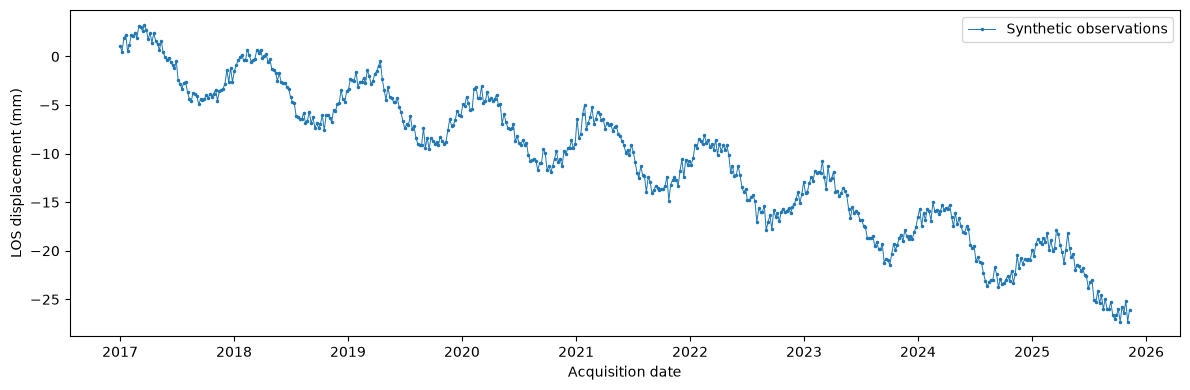

In [7]:
plt.rcParams['figure.facecolor'] = 'white'
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(dt_dats_padded, this_ps_padded, '.-', linewidth=0.7, markersize=3,
        label='Synthetic observations')
ax.set(xlabel='Acquisition date', ylabel='LOS displacement (mm)')
ax.legend()
plt.tight_layout()
plt.show()


## Prepare the modelling signal

Use the noisy displacement observations directly. The original whole-series
zero-phase filter used future measurements; it has been removed to keep each
forecast dependent only on measurements available at its origin. Scaling below
uses training observations only. No whole-series detrending is applied.


In [8]:
this_signal = this_ps_padded.copy()


In [9]:
time = dt_dats_padded


In [10]:
print(f"Signal shape: {this_signal.shape}; input window: {window_size} acquisitions")


Signal shape: (540,); input window: 30 acquisitions


In [11]:
def windowed_dataset(series, window_size, batch_size, shuffle=True):
    """Return batches with inputs [batch, window_size] and targets [batch]."""
    values = np.asarray(series, dtype=np.float32)
    if values.ndim != 1 or len(values) <= window_size:
        raise ValueError("Provide a 1D series longer than window_size.")
    windows = np.lib.stride_tricks.sliding_window_view(values, window_size + 1)
    inputs = torch.from_numpy(windows[:, :-1].copy())
    targets = torch.from_numpy(windows[:, -1].copy())
    generator = torch.Generator().manual_seed(SEED)
    return DataLoader(
        TensorDataset(inputs, targets), batch_size=batch_size,
        shuffle=shuffle, generator=generator,
    )


## Split the dataset chronologically

Keep the original split at acquisition 340 for the 540-observation sample.
For shorter replacement series, use about 65% for training. The remaining
observations are a held-out validation segment and are not used for scaling,
training or epoch selection. The epoch count is fixed above.


In [12]:
split_time = min(340, int(0.65 * len(this_signal)))
if split_time <= window_size or split_time >= len(this_signal):
    raise ValueError("The split must leave training windows and validation targets.")
time_train, time_valid = time[:split_time], time[split_time:]
x_train, x_valid = this_signal[:split_time], this_signal[split_time:]

train_mean = float(x_train.mean())
train_scale = max(float(x_train.std()), 1e-6)
x_train_scaled = (x_train - train_mean) / train_scale
print(f"Training: {len(x_train)} observations; validation: {len(x_valid)} observations")


Training: 340 observations; validation: 200 observations


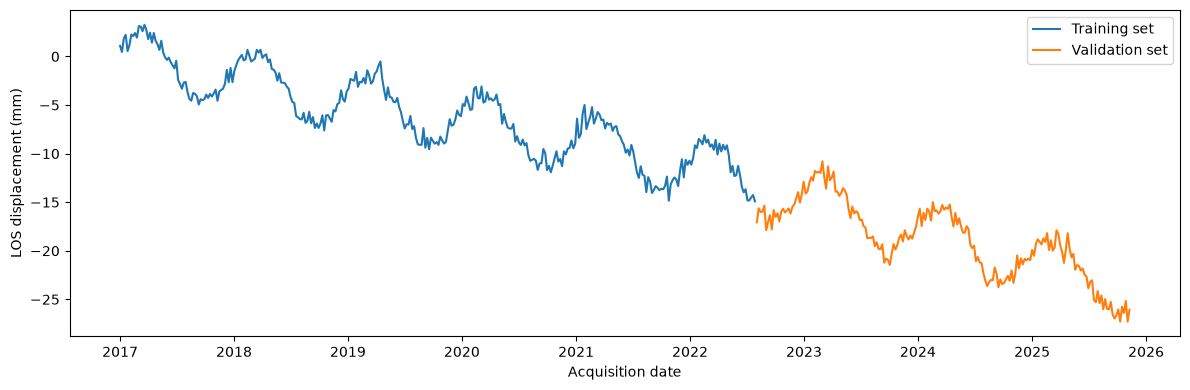

In [13]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(time_train, x_train, label='Training set')
ax.plot(time_valid, x_valid, label='Validation set')
ax.set(xlabel='Acquisition date', ylabel='LOS displacement (mm)')
ax.legend()
plt.tight_layout()
plt.show()


In [14]:
train_set = windowed_dataset(x_train_scaled, window_size, batch_size)
print(f"Training windows: {len(train_set.dataset)}")


Training windows: 310


## The PyTorch model


The architecture follows the original model definition: causal Conv1D with 64
filters and kernel size 3, ReLU, two 64-unit LSTMs, and a linear scalar output
multiplied by 20. Inputs and targets are standardized using training statistics.
The dataset has shape `[batch, window]`; the model rearranges it for PyTorch's
convolution and LSTM layers. Training starts from scratch.


In [15]:
class InSARForecastModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.causal_conv = nn.Sequential(
            nn.ConstantPad1d((2, 0), 0.0),
            nn.Conv1d(1, 64, kernel_size=3),
            nn.ReLU(),
        )
        self.lstm1 = nn.LSTM(64, 64, batch_first=True)
        self.lstm2 = nn.LSTM(64, 64, batch_first=True)
        self.output = nn.Linear(64, 1)

    def forward(self, x):
        x = self.causal_conv(x.unsqueeze(1)).transpose(1, 2)
        x, _ = self.lstm1(x)
        x, _ = self.lstm2(x)
        return self.output(x[:, -1, :]).squeeze(-1) * 20.0

# Reset the seed so rerunning this cell starts from the same initialization.
torch.manual_seed(SEED)
model = InSARForecastModel().to(DEVICE)


Epoch   1/200: training MSE = 0.59737
Epoch  10/200: training MSE = 0.05298
Epoch  20/200: training MSE = 0.03605
Epoch  30/200: training MSE = 0.03547
Epoch  40/200: training MSE = 0.03312
Epoch  50/200: training MSE = 0.03458
Epoch  60/200: training MSE = 0.03133
Epoch  70/200: training MSE = 0.03227
Epoch  80/200: training MSE = 0.02965
Epoch  90/200: training MSE = 0.02583
Epoch 100/200: training MSE = 0.02541
Epoch 110/200: training MSE = 0.02451
Epoch 120/200: training MSE = 0.02691
Epoch 130/200: training MSE = 0.02148
Epoch 140/200: training MSE = 0.02404
Epoch 150/200: training MSE = 0.01598
Epoch 160/200: training MSE = 0.01589
Epoch 170/200: training MSE = 0.01596
Epoch 180/200: training MSE = 0.01566
Epoch 190/200: training MSE = 0.01305
Epoch 200/200: training MSE = 0.01237


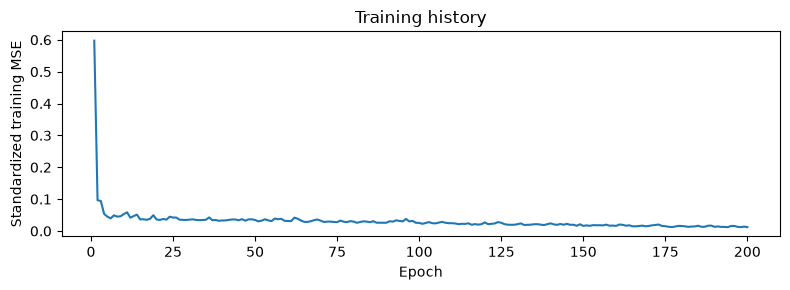

In [16]:
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
loss_fn = nn.MSELoss()
history = []

for epoch in range(1, num_epochs + 1):
    model.train()
    total_loss = 0.0
    for inputs, targets in train_set:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        optimizer.zero_grad()
        loss = loss_fn(model(inputs), targets)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * len(inputs)
    epoch_loss = total_loss / len(train_set.dataset)
    history.append(epoch_loss)
    if epoch == 1 or epoch % 10 == 0:
        print(f"Epoch {epoch:3d}/{num_epochs}: training MSE = {epoch_loss:.5f}")

model.eval()
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(np.arange(1, len(history) + 1), history)
ax.set(xlabel='Epoch', ylabel='Standardized training MSE', title='Training history')
plt.tight_layout()
plt.show()


In [17]:
print(model)
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")


InSARForecastModel(
  (causal_conv): Sequential(
    (0): ConstantPad1d(padding=(2, 0), value=0.0)
    (1): Conv1d(1, 64, kernel_size=(3,), stride=(1,))
    (2): ReLU()
  )
  (lstm1): LSTM(64, 64, batch_first=True)
  (lstm2): LSTM(64, 64, batch_first=True)
  (output): Linear(in_features=64, out_features=1, bias=True)
)
Trainable parameters: 66,881


## Rolling one-step predictions

At each validation date, predict the next observation using the preceding
`window_size` actual measurements. As time advances, newly observed validation
measurements become available as history. This is a sequence of one-step
forecasts, not a forecast of the entire validation segment from a single origin.


In [18]:
@torch.no_grad()
def predict_windows(windows):
    """Predict a batch of raw displacement windows; return a 1D array in mm."""
    model.eval()
    windows = np.asarray(windows, dtype=np.float32)
    if windows.ndim != 2 or windows.shape[1] != window_size:
        raise ValueError(f"Expected windows with shape [batch, {window_size}].")
    scaled = (windows - train_mean) / train_scale
    inputs = torch.from_numpy(np.ascontiguousarray(scaled)).to(DEVICE)
    return model(inputs).cpu().numpy() * train_scale + train_mean

forecast_series = this_signal[split_time - window_size:]
forecast_windows = np.lib.stride_tricks.sliding_window_view(
    forecast_series, window_size + 1
)[:, :-1].copy()
results = predict_windows(forecast_windows)
assert results.shape == x_valid.shape


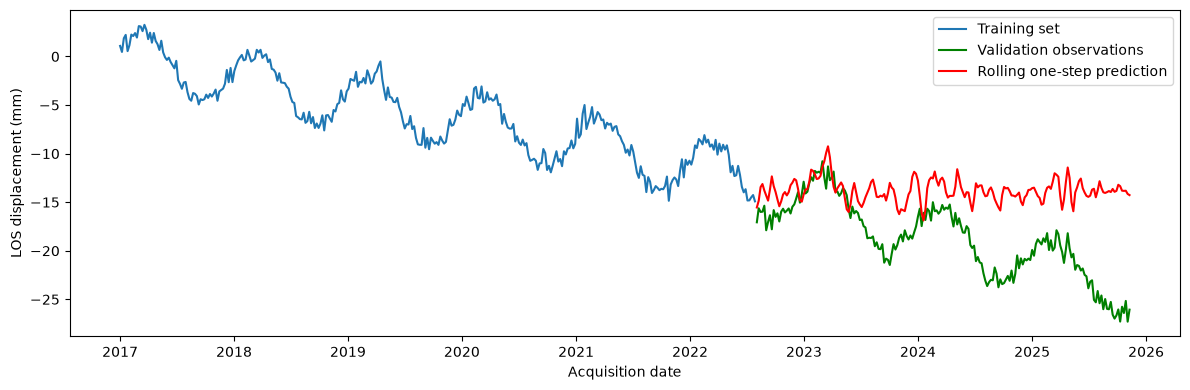

In [19]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(time_train, x_train, label='Training set')
ax.plot(time_valid, x_valid, color='green', label='Validation observations')
ax.plot(time_valid, results, color='red', label='Rolling one-step prediction')
ax.set(xlabel='Acquisition date', ylabel='LOS displacement (mm)')
ax.legend()
plt.tight_layout()
plt.show()


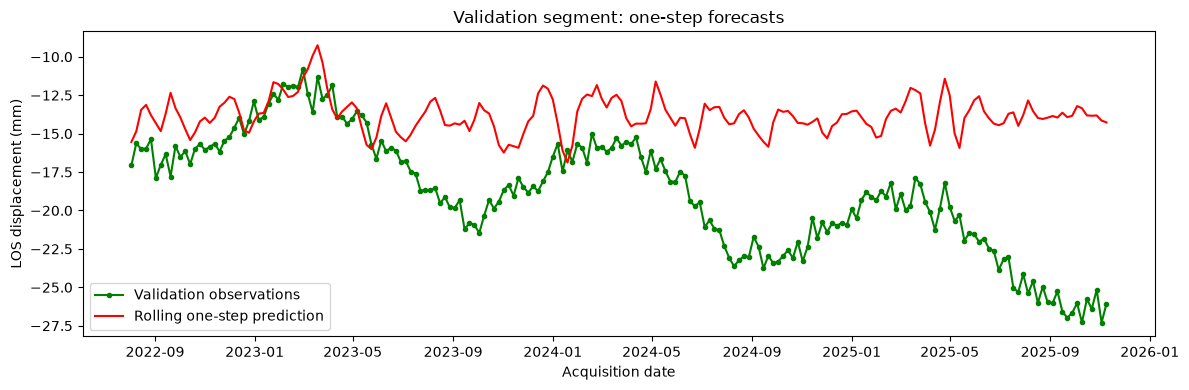

In [20]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(time_valid, x_valid, '.-', color='green', label='Validation observations')
ax.plot(time_valid, results, color='red', label='Rolling one-step prediction')
ax.set(xlabel='Acquisition date', ylabel='LOS displacement (mm)',
       title='Validation segment: one-step forecasts')
ax.legend()
plt.tight_layout()
plt.show()


In [21]:
def forecast_metrics(actual, predicted):
    error = np.asarray(predicted) - np.asarray(actual)
    return {"MSE_mm2": float(np.mean(error ** 2)), "MAE_mm": float(np.mean(np.abs(error)))}

# Persistence uses the most recently available observation at each origin.
persistence = this_signal[split_time - 1:-1]
rolling_metrics = pd.DataFrame({
    "PyTorch one-step": forecast_metrics(x_valid, results),
    "Persistence one-step": forecast_metrics(x_valid, persistence),
}).T
rolling_metrics


,MSE_mm2,MAE_mm
PyTorch one-step,38.542747,5.105231
Persistence one-step,0.877296,0.766841


## Recursive predictions

Start with the last training window and feed each prediction back into the next
input. No validation measurements enter this forecast. Errors can accumulate
over the full validation horizon, so compare it with the rolling forecast and a
fixed-origin persistence baseline.


In [22]:
native_forecast = []
native_forecast_window = this_signal[split_time - window_size:split_time].copy()

for _ in range(len(x_valid)):
    next_value = float(predict_windows(native_forecast_window[None, :])[0])
    native_forecast.append(next_value)
    native_forecast_window = np.concatenate([
        native_forecast_window[1:], np.array([next_value], dtype=np.float32)
    ])

native_results = np.asarray(native_forecast, dtype=np.float32)
assert native_results.shape == x_valid.shape


[W925 16:34:32.624656265 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W925 16:34:32.629357447 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W925 16:34:32.631211505 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W925 16:34:32.632798847 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W925 16:34:32.634560198 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W925 16:34:32.645281531 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W925 16:34:32.648317753 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W925 16:34:32.650301446 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W925 16:34:32.652031370 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W925 16:34:32.653583953 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W925 16:3

In [23]:
mse = (native_results - x_valid) ** 2  # squared error at each forecast lead


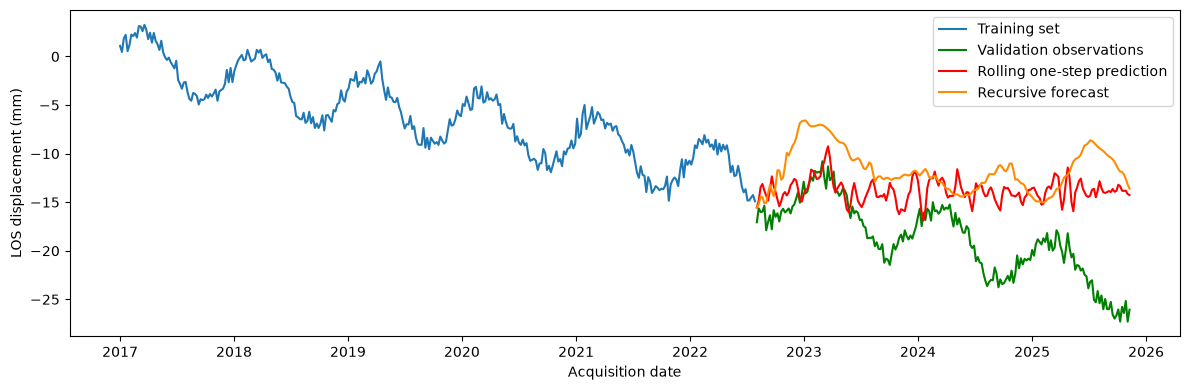

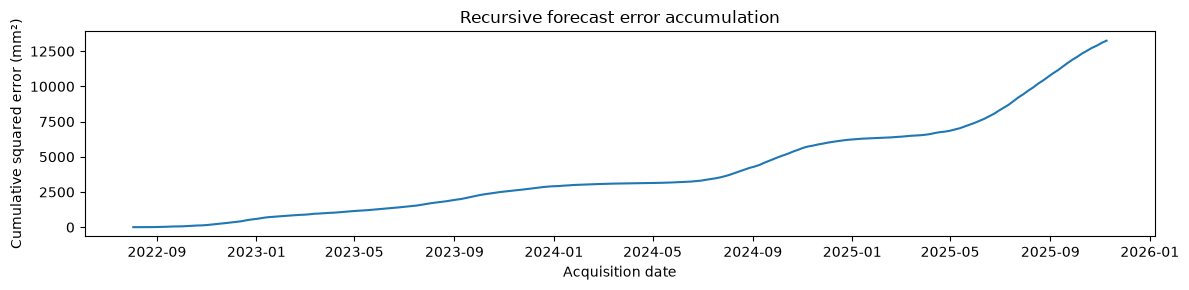

In [24]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(time_train, x_train, label='Training set')
ax.plot(time_valid, x_valid, color='green', label='Validation observations')
ax.plot(time_valid, results, color='red', label='Rolling one-step prediction')
ax.plot(time_valid, native_results, color='darkorange', label='Recursive forecast')
ax.set(xlabel='Acquisition date', ylabel='LOS displacement (mm)')
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(time_valid, np.cumsum(mse))
ax.set(xlabel='Acquisition date', ylabel='Cumulative squared error (mm²)',
       title='Recursive forecast error accumulation')
plt.tight_layout()
plt.show()


The recursive forecast is generated entirely from the final training window,
whereas the rolling forecast receives a new actual measurement at each step.
Their information differs, so lower rolling error is not evidence that a long
recursive forecast is reliable. Inspect the scores and plots from this run;
the original claims about forecast duration do not carry over to these data.


In [25]:
recursive_persistence = np.full_like(x_valid, x_train[-1])
recursive_metrics = pd.DataFrame({
    "PyTorch recursive": forecast_metrics(x_valid, native_results),
    "Persistence fixed origin": forecast_metrics(x_valid, recursive_persistence),
}).T
recursive_metrics


,MSE_mm2,MAE_mm
PyTorch recursive,66.247269,7.162750
Persistence fixed origin,29.741371,4.409268
